## <font color='blue'>Projeto Tratamento de Valores Ausentes</font>
## <font color='blue'>Análise de Dados Para Campanhas de Marketing de Instituições Financeiras</font>

### Imputação

A  imputação  para  **variáveis  quantitativas**  `visa  substituir  valores  ausentes  por  valores numéricos` que representem a informação contida na variável. A principal técnica de imputação nesse caso é usar uma medida de tendência central da variável e então imputar os valores ausentes com essa medida. `As medidas de tendência central são: média, mediana e moda`

Outra técnica para imputação de variáveis quantitativas é usar o `forward ou backward fill` preenchendo o valor ausente com o último valor válido, fazendo isso para frente (forward) ou para trás (backward).

*Podemos ainda usar Machine Learning para prever o valor ausente e então realizar a imputação.*

Para **variáveis qualitativas** a  técnica mais  comum é a  `imputação  múltipla`,  quando verificamos os valores ausentes e checamos as regras associadas a outras variáveis

Outra alternativa é `criar uma nova categoria e preencher os valores ausentes. “Não Definido”`, por exemplo.

Podemos ainda preencher o valor ausente com a categoria mais frequente

## Definição do Problema:

Vamos analisar dados referentes a `campanhas de marketing` direto de uma `instituição bancária`  portuguesa.  As  campanhas  de  marketing  foram  baseadas  em  ligações  telefônicas. Muitas vezes, era necessário mais de um contato para o mesmo cliente, a fim de saberse o `produto (depósito bancário a prazo) seria ('sim') ou não ('não') adquirido pelo cliente`.O dataset apresenta diversos problemas pois é um dataset com dados reais. Daremos ênfase ao tratamento de valores ausentes, mas também faremos a limpeza e tratamento de outros eventuais problemas que detectarmos.

## Fonte de Dados:

https://archive.ics.uci.edu/ml/datasets/bank+marketing

*Entretanto, fizemos diversas modificações provocando problemas nos dados para que possamos trabalhar na limpeza e análise*

## Instalando e Carregando os Pacotes

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Carregando os Dados

In [2]:
# Carrega o dataset
df = pd.read_csv("dataset.csv") 

In [3]:
# Shape
df.shape

(45211, 19)

In [4]:
# Amostra
df.head()

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000.0,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000.0,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000.0,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,4,47.0,20000.0,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,5,33.0,0.0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


## Análise Exploratória

In [5]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  45211 non-null  int64  
 1   age         45191 non-null  float64
 2   salary      45185 non-null  float64
 3   balance     45211 non-null  int64  
 4   marital     45211 non-null  object 
 5   jobedu      45211 non-null  object 
 6   targeted    45211 non-null  object 
 7   default     45211 non-null  object 
 8   housing     45211 non-null  object 
 9   loan        45211 non-null  object 
 10  contact     45211 non-null  object 
 11  day         45211 non-null  int64  
 12  month       45161 non-null  object 
 13  duration    45211 non-null  object 
 14  campaign    45211 non-null  int64  
 15  pdays       45211 non-null  int64  
 16  previous    45211 non-null  int64  
 17  poutcome    45211 non-null  object 
 18  response    45181 non-null  object 
dtypes: float64(2), int64(6), 

In [6]:
# Temos valores nulos?
df.isna().sum()

customerid     0
age           20
salary        26
balance        0
marital        0
jobedu         0
targeted       0
default        0
housing        0
loan           0
contact        0
day            0
month         50
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
response      30
dtype: int64

In [7]:
# Não usaremos a coluna ID. Vamos removê-la.

df.drop(["customerid"], axis = 1, inplace = True)

In [8]:
# Colunas

df.columns

Index(['age', 'salary', 'balance', 'marital', 'jobedu', 'targeted', 'default',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'response'],
      dtype='object')

# Primeiro problema:

Coluna **jobedu** parece ter duas informações na mesma coluna. Vamos separar em duas colunas

In [9]:
df.head()

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000.0,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44.0,60000.0,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,33.0,120000.0,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,47.0,20000.0,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,33.0,0.0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


In [10]:
# Fazemos o split da coluna jobedu e criamos a coluna job com o primeiro elemento antes da vírgula
df[['job', 'education']] = df['jobedu'].str.split(',', expand=True)

In [11]:
df.head()

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58.0,100000.0,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44.0,60000.0,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33.0,120000.0,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47.0,20000.0,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33.0,0.0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown


In [12]:
# Comparando as colunas

df[['job', 'education', 'jobedu']]

,job,education,jobedu
0,management,tertiary,"management,tertiary"
1,technician,secondary,"technician,secondary"
2,entrepreneur,secondary,"entrepreneur,secondary"
3,blue-collar,unknown,"blue-collar,unknown"
4,unknown,unknown,"unknown,unknown"
...,...,...,...
45206,technician,tertiary,"technician,tertiary"
45207,retired,primary,"retired,primary"
45208,retired,secondary,"retired,secondary"
45209,blue-collar,secondary,"blue-collar,secondary"


In [13]:
# Drop da coluna "jobedu" 

df.drop(["jobedu"], axis = 1, inplace = True)

In [14]:
df.head()

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58.0,100000.0,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44.0,60000.0,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33.0,120000.0,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47.0,20000.0,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33.0,0.0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown


## Tratamento de Valores Ausentes

> Vamos primeiro tratar a variável que representa a idade.

# Variável "age"

In [16]:
# Valores ausentes no dataframe
df.isna().sum()

age          20
salary       26
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month        50
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

In [17]:
# Valores ausentes da variável age

df.age.isna().sum()

np.int64(20)

In [18]:
# Calcula o percentual de valores ausentes na variável age

df['age'].isna().mean()*100 #isnull()

np.float64(0.0442370219636814)

Como o percentual é baixo não podemos eliminar a coluna. Podemos então eliminar os registros com valores ausentes (nesse caso perderíamos 20 linhas no dataset) ou podemos aplicar imputação. Vamos usar a segunda opção.

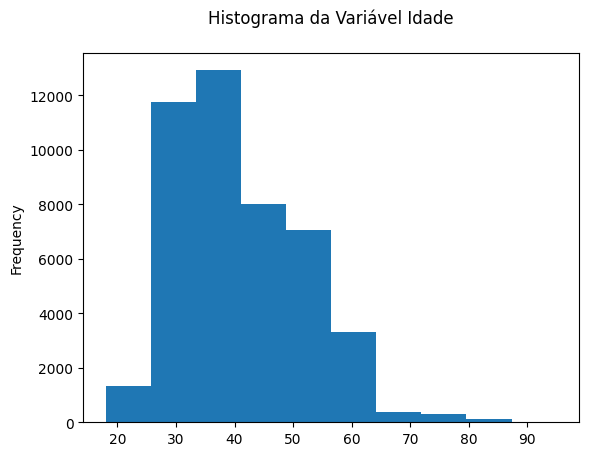

In [19]:
# Histograma

df.age.plot(kind = "hist")
plt.title("Histograma da Variável Idade\n")
plt.show()

Maioria das pessoas tem entre 30 e 40 anos

In [ ]:
#plt.figure(figsize=(10,3))
#ax= sns.histplot(data=df, x= 'age', kde=True)
#plt.show()

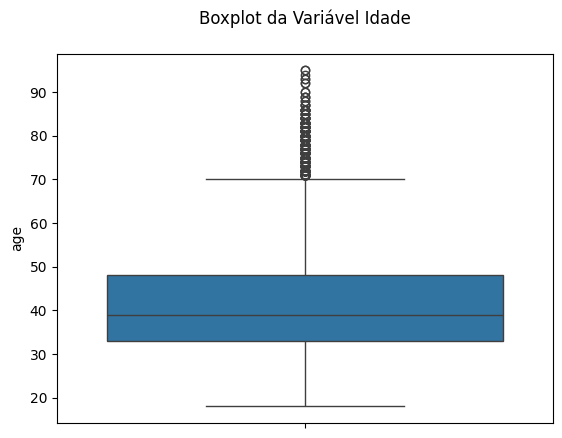

In [20]:
# Boxplot

sns.boxplot(df.age)
plt.title("Boxplot da Variável Idade\n")
plt.show()

Os dados estão Assimetricos com muitos outliers. Não podemos usar a média

In [ ]:
#plt.figure(figsize=(10,3))
#ax= sns.boxplot(data=df, x= 'age')
#plt.show()

In [21]:
# Vamos verificar qual é a média de idade.
df.age.mean()

np.float64(40.93565090394105)

In [22]:
# Vamos verificar qual é a mediana, valor do meio da distribuição quando os dados estão ordenados.
df.age.median()

39.0

In [23]:
# Vamos verificar qual é a moda, o valor que aparece com mais frequência.
df.age.mode()

0    32.0
Name: age, dtype: float64

## Imputando a medida de tendência central:

## Vamos preencher com a `MODA` pois são poucos valores ausentes e assim alteramos muito pouco os padrões dos dados

In [24]:
# Vamos preencher com a moda pois são poucos valores ausentes e assim alteramos muito pouco o padrão nos dados.

#df['age'].fillna('32', inplace=True)
df.age.fillna("32", inplace = True)

In [25]:
# Agora convertemos para int

df.age = df.age.astype("int")

In [26]:
# Tipo da variável
df.age.dtypes

dtype('int64')

In [27]:
# Média
df.age.mean()

np.float64(40.93169803808808)

In [28]:
# Mediana
df.age.median()

39.0

In [29]:
# Percentual de valores ausentes
df.age.isna().mean()*100

np.float64(0.0)

In [30]:
df.age.isna().sum()

np.int64(0)

## Tratamento de Valores Ausentes

> Vamos agora tratar a variável que representa o mês.

# Variavel "month"

In [31]:
# Valores ausentes no dataframe
df.isna().sum()

age           0
salary       26
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month        50
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

In [32]:
# Valores ausentes na variável
df.month.isna().sum()

np.int64(50)

In [33]:
# Percentual de valores ausentes
df.month.isnull().mean()*100

np.float64(0.11059255490920351)

Como o percentual é menor que 30% não podemos eliminar a coluna. Podemos então eliminar os registros com valores ausentes (nesse caso perderíamos 50 linhas no dataset) ou podemos aplicar imputação. Vamos usar a segunda opção.

In [34]:
# Tipo da variável
df.month.dtypes

dtype('O')

In [35]:
# Categorias da variável
df.month.value_counts()

month
may, 2017    13747
jul, 2017     6888
aug, 2017     6240
jun, 2017     5335
nov, 2017     3968
apr, 2017     2931
feb, 2017     2646
jan, 2017     1402
oct, 2017      738
sep, 2017      576
mar, 2017      476
dec, 2017      214
Name: count, dtype: int64

## Imputação de valores ausentes - Variável "month" Usaremos o **Fillna()**

#### Vamos usar a `MODA` (o valor que aparece com mais frequencia na variável) `pois são poucos registros`

In [36]:
# Vamos imputar com a moda, o valor mais frequente da variável, pois são poucos registros
df.month.mode()

0    may, 2017
Name: month, dtype: object

In [37]:
# Imputação com a moda
df.month.fillna("may, 2017", inplace = True)

In [38]:
# Valores ausentes tratados com sucesso
df.month.isna().sum()

np.int64(0)

## Tratamento de Valores Ausentes

> Vamos agora tratar a variável que representa o salário.

# Variável "salary"

In [39]:
# Valores ausentes no dataframe
df.isna().any()

age          False
salary        True
balance      False
marital      False
targeted     False
default      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
response      True
job          False
education    False
dtype: bool

In [43]:
# Valores ausentes na variável
df.salary.isnull().sum()

26

In [40]:
# Calcula o percentual de valores ausentes na variável salary
df.salary.isna().mean()*100

np.float64(0.05750812855278583)

Como o percentual é baixo não podemos eliminar a coluna. Podemos então eliminar os registros com valores ausentes (nesse caso perderíamos 26 linhas no dataset) ou podemos aplicar **`IMPUTAÇÃO`**. Vamos usar a segunda opção.


In [41]:
df.head()

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000.0,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000.0,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33,120000.0,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47,20000.0,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33,0.0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown


#### **OBS:** Não existe salario igual à 0.0, provavelmente o valor representa um `valor ausente(ausencia de informação)`

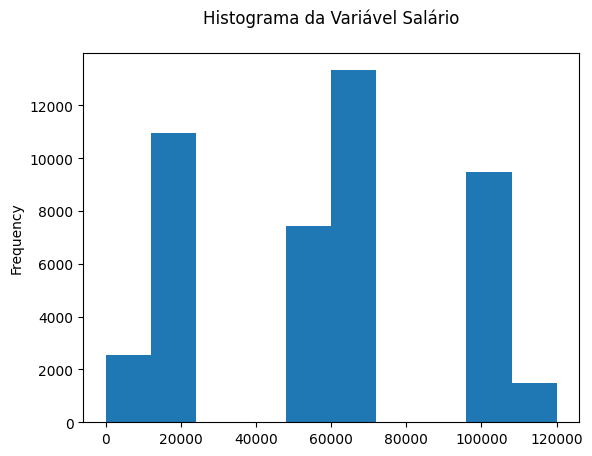

In [42]:
# Histograma

df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

Não segue uma distribuição normal

In [43]:
#plt.figure(figsize=(7,3))
#ax = sns.histplot(data= df, x= 'salary')
#plt.show()

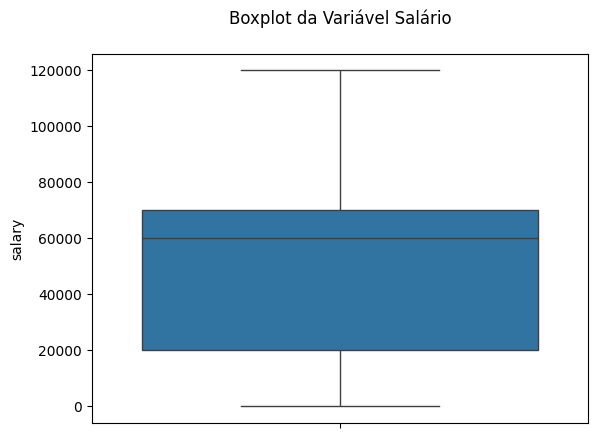

In [44]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

In [45]:
#plt.figure(figsize=(7,3))
#ax= sns.boxplot(data=df, x= 'salary')
#plt.show()

In [46]:
# Vamos verificar qual é a média de idade.

df.salary.mean()

np.float64(57008.65331415293)

In [47]:
# Vamos verificar qual é a mediana.
df.salary.median()

60000.0

In [48]:
# Vamos verificar qual é a moda.
df.salary.mode()

0    20000.0
Name: salary, dtype: float64

In [49]:
df.salary.value_counts(dropna=False)

salary
20000.0     9725
100000.0    9454
60000.0     9169
50000.0     5167
70000.0     4153
55000.0     2264
120000.0    1486
8000.0      1303
16000.0     1239
4000.0       937
0.0          288
NaN           26
Name: count, dtype: int64

#### **OBS:** A maioria dos salarios está abaixo da mediana (linha que corta o intervalo interquartil (candle))

In [50]:
# Vamos preencher com a mediana pois os dados parecem assimétricos (nesse caso a média não pode ser usada) 
# e o valor mais frequente está muito abaixo da média e da mediana (por isso não usaremos a moda)

df.salary.fillna("60000", inplace = True)

In [51]:
df.head()

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000.0,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000.0,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33,120000.0,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47,20000.0,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33,0.0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown


**OBS:** O fillna transformou os dados em object por causa "60000" PODE SER FEITO SEM AS ASPAS

In [53]:
# Tipo da variável
df.salary.dtypes

dtype('O')

In [54]:
# Convertemos para o tipo float

df.salary = df.salary.astype("float")

In [55]:
# Tipo da variável
df.salary.dtypes

dtype('float64')

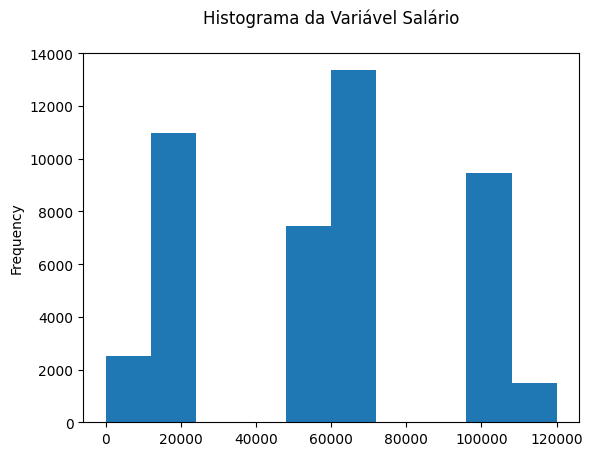

In [56]:
# Histograma
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

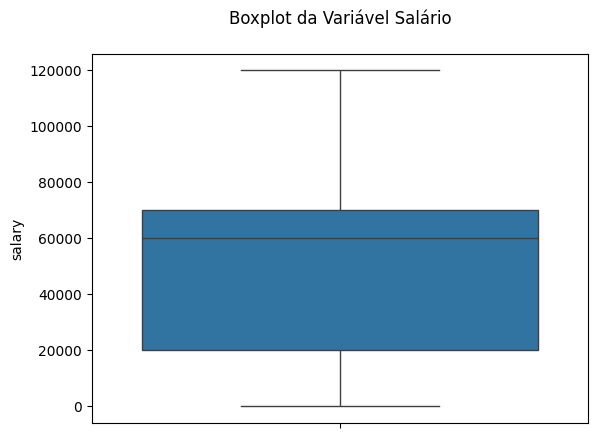

In [57]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

In [58]:
# Registros para cada salário
df.salary.value_counts()

salary
20000.0     9725
100000.0    9454
60000.0     9195
50000.0     5167
70000.0     4153
55000.0     2264
120000.0    1486
8000.0      1303
16000.0     1239
4000.0       937
0.0          288
Name: count, dtype: int64

>288 registros igual a 0.0

>Os valores NaN vão ser tratados com a mediana

In [59]:
# Replace do zero pela mediana

df['salary'] = df['salary'].replace(0, df['salary'].median())

In [60]:
# Registros para cada salário
df.salary.value_counts()

salary
20000.0     9725
60000.0     9483
100000.0    9454
50000.0     5167
70000.0     4153
55000.0     2264
120000.0    1486
8000.0      1303
16000.0     1239
4000.0       937
Name: count, dtype: int64

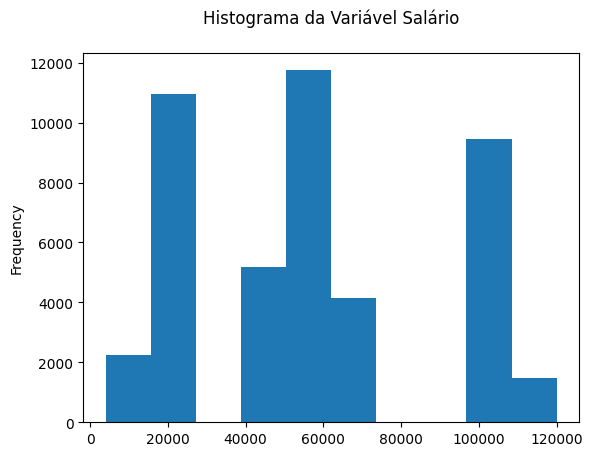

In [61]:
# Histograma
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

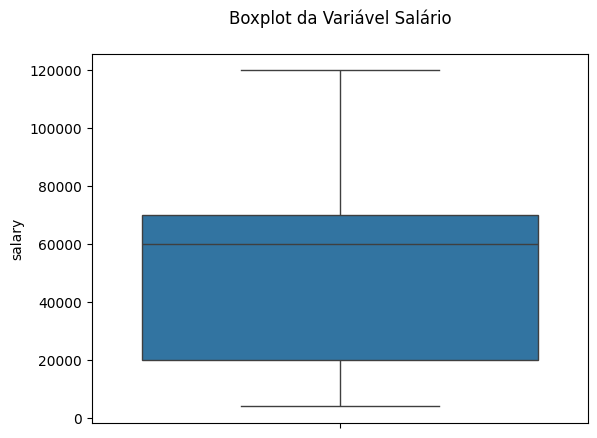

In [62]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

#### Checando o resultado:

In [63]:
# Calcula o percentual de valores ausentes na variável salary
df.salary.isnull().mean()*100

np.float64(0.0)

In [64]:
df.isna().sum()

age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

## Tratamento de Valores Ausentes

> Vamos agora tratar a variável que representa a resposta (variável alvo).

# Variável "response"

In [65]:
df.head()

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000.0,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000.0,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33,120000.0,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47,20000.0,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33,60000.0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown


In [66]:
# Valores ausentes
df.response.isnull().sum()

np.int64(30)

In [67]:
# Calcula o percentual
df.response.isnull().mean()*100

np.float64(0.0663555329455221)

Como o percentual é baixo (e a variável é o alvo da nossa análise) Não podemos fazer imputação. Podemos então Eliminar os registros com valores ausentes (nesse caso perderíamos 30 linhas no dataset).

In [68]:
df.response.value_counts(dropna=False)

response
no     39894
yes     5287
NaN       30
Name: count, dtype: int64

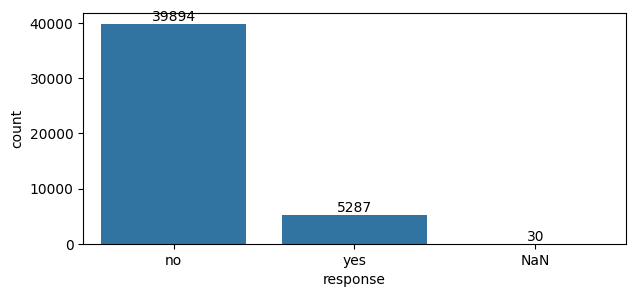

In [69]:
plt.figure(figsize=(7,3))

ax= sns.countplot(data= df.fillna('NaN'), x= 'response')

ax.bar_label(ax.containers[0])

plt.show()

In [70]:
# Não devemos aplicar imputação na variável de estudo (variável resposta ou variável alvo)
# Vamos dropar os registros

df.dropna(subset = ["response"], inplace = True)

In [71]:
# Verifca valores NA
df.isnull().sum()

age          0
salary       0
balance      0
marital      0
targeted     0
default      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
response     0
job          0
education    0
dtype: int64

## Tratamento de Valores Ausentes

> Vamos agora tratar a variável pdays.

# Variável 'pdays'

OBS: Não há ausencia de dados mas tem ausencia de informação -1 indica valor ausente

In [72]:
# Valores ausentes
df.pdays.isna().sum()

np.int64(0)

In [73]:
# Describe
df.pdays.describe()

count    45181.000000
mean        40.198601
std        100.134050
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

-1 indica valor ausente

In [74]:
# Vamos fazer relace de -1 por NaN

df['pdays'] = df['pdays'].replace(-1, np.nan)

In [75]:
# Valores ausentes
df.isna().sum()

age              0
salary           0
balance          0
marital          0
targeted         0
default          0
housing          0
loan             0
contact          0
day              0
month            0
duration         0
campaign         0
pdays        36930
previous         0
poutcome         0
response         0
job              0
education        0
dtype: int64

In [76]:
# Calcula o percentual
df.pdays.isnull().mean()*100

np.float64(81.73789867422147)

#### Vamos fazer o drop da coluna "pdays" pois possue mais de 30% de Valores Ausentes

In [77]:
# Drop da coluna "pdays" pois tem mais de 30% dos valores ausentes

df.drop(['pdays'], axis=1, inplace=True)

In [78]:
# Valores ausentes
df.isnull().sum()

age          0
salary       0
balance      0
marital      0
targeted     0
default      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
previous     0
poutcome     0
response     0
job          0
education    0
dtype: int64

## Conclusão e Análise dos Dados

### Análise Univariada

In [79]:
# Proporção da variável de estado civil
df.marital.value_counts(normalize = True)

marital
married     0.601912
single      0.282907
divorced    0.115181
Name: proportion, dtype: float64

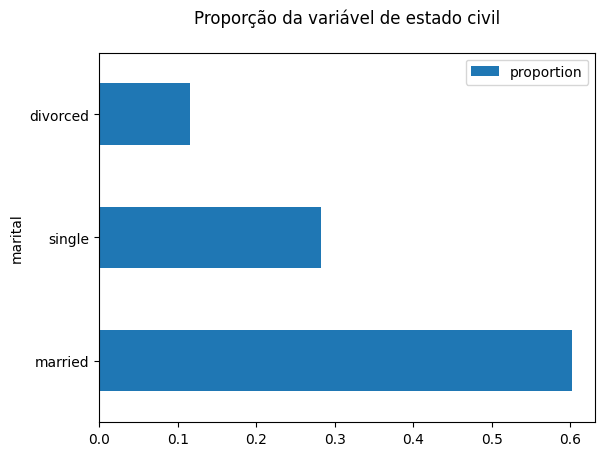

In [80]:
# Plot
df.marital.value_counts(normalize = True).plot(kind = "barh")
plt.title("Proporção da variável de estado civil\n")
plt.legend()
plt.show()

In [81]:
# Proporção da variável de job
df.job.value_counts(normalize = True)

job
blue-collar      0.215290
management       0.209247
technician       0.168035
admin.           0.114340
services         0.091853
retired          0.050087
self-employed    0.034860
entrepreneur     0.032890
unemployed       0.028840
housemaid        0.027423
student          0.020761
unknown          0.006374
Name: proportion, dtype: float64

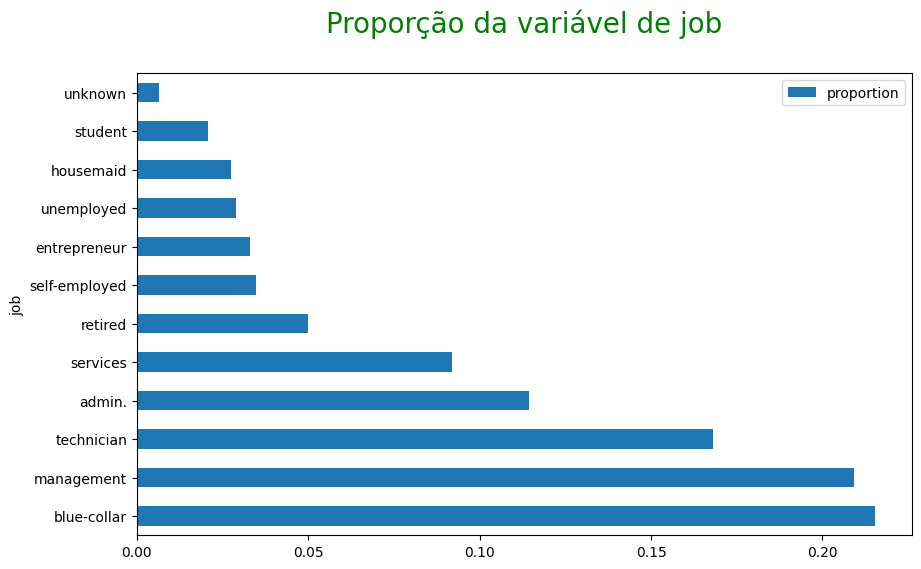

In [82]:
# Plot
plt.figure(figsize = (10,6))
df.job.value_counts(normalize = True).plot(kind = "barh")
plt.title("Proporção da variável de job\n", fontdict = {'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})
plt.legend()
plt.show()

In [83]:
# Proporção da variável de education
df.education.value_counts(normalize = True)

education
secondary    0.513247
tertiary     0.294194
primary      0.151480
unknown      0.041079
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

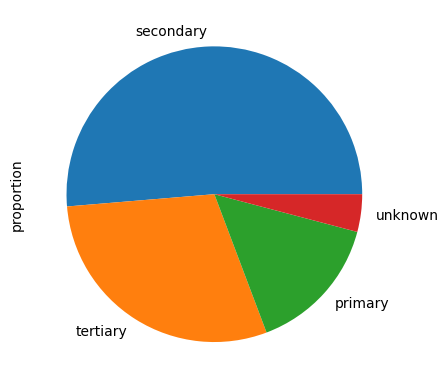

In [84]:
# Plot
df.education.value_counts(normalize=True).plot(kind= 'pie')

In [85]:
# Proporção da variável response
df.response.value_counts(normalize = True)

response
no     0.882982
yes    0.117018
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

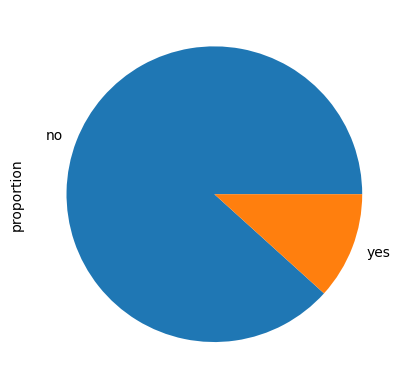

In [86]:
# Plot
df.response.value_counts(normalize=True).plot(kind='pie')

## Análise Multivariada

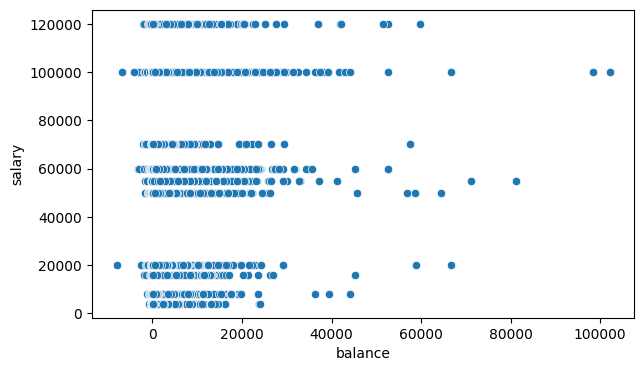

In [87]:
# Scatter Plot
plt.figure(figsize=(7,4))

ax = sns.scatterplot(data=df, x= 'balance', y= 'salary')

plt.show()

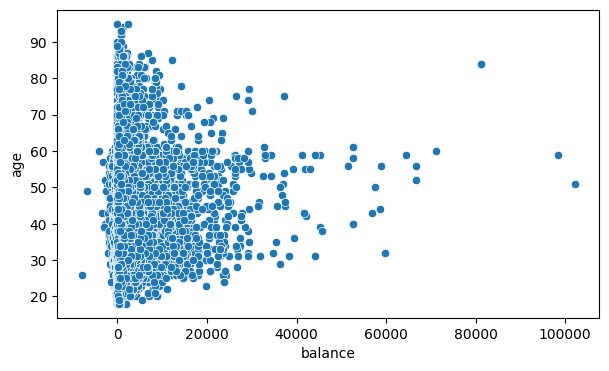

In [88]:
# Scatter Plot
plt.figure(figsize=(7,4))

ax= sns.scatterplot(data= df, x= 'balance', y= 'age')

plt.show()

Resultado: Até tem algum padrão. A medida que a idade aumenta parece haver um pequeno aumento no saldo bancario

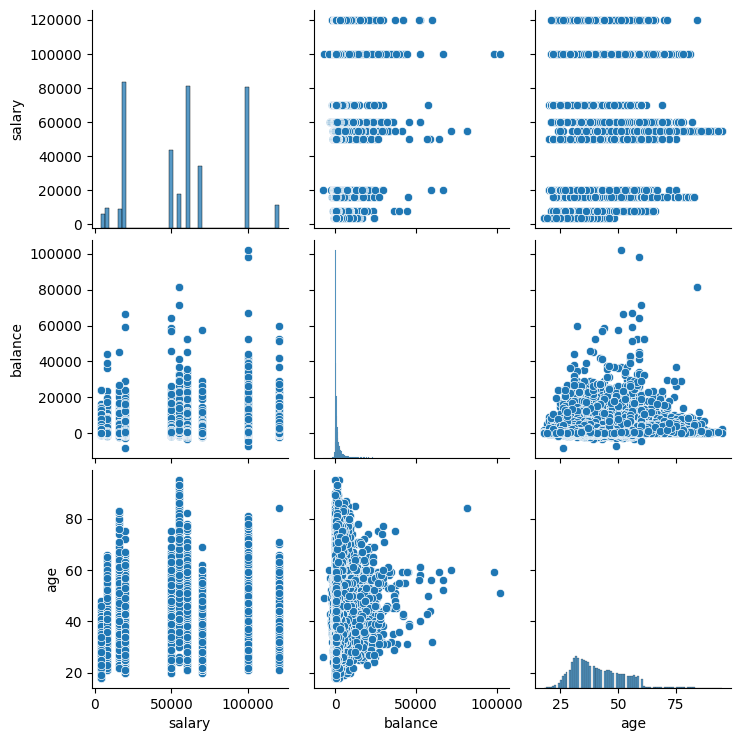

In [89]:
# Pair Plot
sns.pairplot(df[["salary","balance","age"]])
plt.show()

In [90]:
# Calcula a correlação

cor = df[['salary','balance', 'age']].corr()

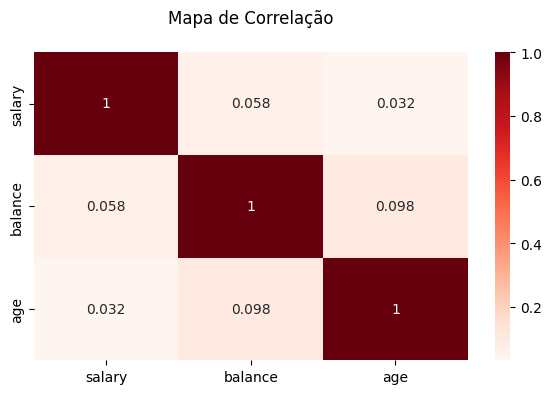

In [91]:
# Mapa de Correlação
plt.figure(figsize=(7,4))

ax = sns.heatmap(cor, annot=True, cmap='Reds') #annot=True é pra por os valores

plt.title('Mapa de Correlação\n')

plt.show()

Resultado: Não há uma correlação forte entre as variaveis, não tem uma relação direta

### Numérico x Categórico

In [92]:
# Agrupa o salário pela variável resposta e calcula a média
df.groupby(by = ["response"])["salary"].mean()

response
no     57157.692886
yes    59157.556270
Name: salary, dtype: float64

**Resultado:**

Quem não(no) comprou o produto tinha como média salarial: 57157.69

Quem comprou(yes) o produto tinha como média salarial: 57157.69

In [93]:
# Agrupa o salário pela variável resposta e calcula a mediana
df.groupby(by = ["response"])["salary"].median()

response
no     60000.0
yes    60000.0
Name: salary, dtype: float64

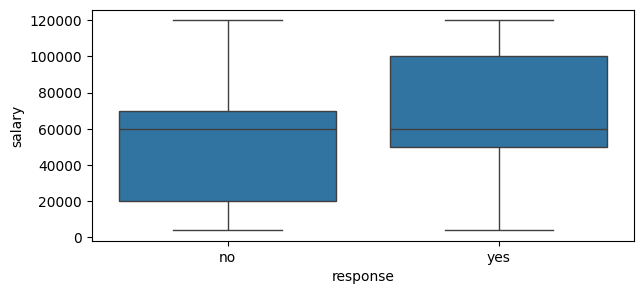

In [94]:
# Boxplot
plt.figure(figsize=(7,3))
ax = sns.boxplot(data= df, x='response', y='salary')
plt.show()

Quem não comprou tinha o salario abaixo da mediana, e quem comprou tinha o salario acima da mediana

In [95]:
# Agrupa educação por salário e calcula a média
df.groupby(by = ["education"])["salary"].mean()

education
primary      34697.106955
secondary    49922.420113
tertiary     83041.077340
unknown      50708.512931
Name: salary, dtype: float64

A medida que aumenta o nivel educacional o salario aumenta

In [96]:
# Cria a variável response_flag como tipo numérico onde response "yes"= 1, "no"= 0

df["response_flag"] = np.where(df["response"] == "yes",1,0)
df.head()

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,previous,poutcome,response,job,education,response_flag
0,58,100000.0,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,0,unknown,no,management,tertiary,0
1,44,60000.0,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,0,unknown,no,technician,secondary,0
2,33,120000.0,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,0,unknown,no,entrepreneur,secondary,0
3,47,20000.0,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,0,unknown,no,blue-collar,unknown,0
4,33,60000.0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,0,unknown,no,unknown,unknown,0


Foi feito isso para poder criar uma mapa de correlação

In [97]:
mpcor = df.pivot_table(index='education', columns='marital', values='response_flag', aggfunc= 'mean')

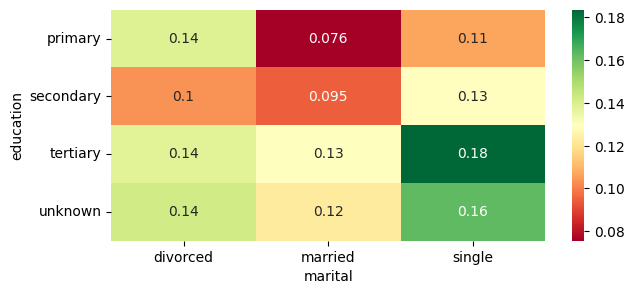

In [98]:
# Mapa de correlação
plt.figure(figsize=(7,3))
ax = sns.heatmap(mpcor, annot=True, cmap = 'RdYlGn')
plt.show()

Resultado: Quando a pessoa era solteira(single), e tinha ensino superior(tertiary): tinha uma alta correlação com a variavel resposta(response_flag)

ou seja: Comprou o produto bancário!!!!! 

Quando era casado(marital) e com ensino primario(primary) não comprava o produto!

# Fim